# Gemini Robotics-ER 1.5

This notebook addapts the google intro book for the **Gemini Robotics-ER 1.5** model. Our focus is on dense semantic labelling, so I've left in the 2d pointing and bounding box examples as they may be useful later on.The original repo is under Apache 2.0
## Documentation

For more details on the Gemini Robotics-ER 1.5 model, see the [documentation](https://ai.google.dev/gemini-api/docs/robotics-overview).

## Setup

This section will need to be run any time you start up Colab. The example sections following this are intended to be able to be run without reliance on any other example section, so you may skip through to the examples that are most relevant/interesting to you at the time (though it is strongly recommended that you read through each of these examples at least once!)

### Install SDK

In [ ]:
%pip install -U -q google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 239.4/239.4 kB 15.6 MB/s eta 0:00:00


### Setup your API key

To run the following cells, your API key must be stored it in a Colab Secret named `GOOGLE_API_KEY`. If you don't already have an API key, or you're not sure how to create a Colab Secret, see [Authentication](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Authentication.ipynb) for an example.

In [ ]:
from google.colab import userdata

GOOGLE_API_KEY = userdata.get("Trace")

### Initialize SDK client

Initialize a Gemini SDK client with your API key.

In [ ]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GOOGLE_API_KEY)

### Select the Gemini Robotics-ER 1.5 model and test


In [ ]:
MODEL_ID = "gemini-robotics-er-1.5-preview"

print(
    client.models.generate_content(
        model=MODEL_ID, contents="Are you there?"
    ).text
)

Yes, I am here. How can I help you?


### Imports and utility code

#### Imports

In [ ]:
import json
import textwrap
import time

#### Parsing JSON output

In [ ]:
def parse_json(json_output):
  # Parsing out the markdown fencing
  lines = json_output.splitlines()
  for i, line in enumerate(lines):
    if line == "```json":
      # Remove everything before "```json"
      json_output = "\n".join(lines[i + 1 :])
      # Remove everything after the closing "```"
      json_output = json_output.split("```")[0]
      break  # Exit the loop once "```json" is found
  return json_output

#### Resize images

Resize images for faster rendering and smaller API calls.

In [ ]:
from PIL import Image

def get_image_resized(img_path):
    img = Image.open(img_path)
    img = img.resize(
        (800, int(800 * img.size[1] / img.size[0])), Image.Resampling.LANCZOS
    )
    return img

#### Visualization helpers

In [ ]:
import base64
import dataclasses
from io import BytesIO
import numpy as np
from PIL import ImageColor, ImageDraw, ImageFont
from typing import Tuple

import IPython
from IPython import display

def generate_point_html(pil_image, points_json):
  buffered = BytesIO()
  pil_image.save(buffered, format="PNG")
  img_str = base64.b64encode(buffered.getvalue()).decode()
  points_json = parse_json(points_json)

  return f"""
<!DOCTYPE html>
<html>
<head>
    <title>Point Visualization</title>
    <style>
        body {{
            margin: 0;
            padding: 0;
            background: #fff;
            color: #000;
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
        }}

        .point-overlay {{
            position: absolute;
            top: 0;
            left: 0;
            width: 100%;
            height: 100%;
            pointer-events: none;
        }}

        .point {{
            position: absolute;
            width: 12px;
            height: 12px;
            background-color: #2962FF;
            border: 2px solid #fff;
            border-radius: 50%;
            transform: translate(-50%, -50%);
            box-shadow: 0 0 40px rgba(41, 98, 255, 0.6);
            opacity: 0;
            transition: all 0.3s ease-in;
            pointer-events: auto;
        }}

        .point.visible {{
            opacity: 1;
        }}

        .point.fade-out {{
            animation: pointFadeOut 0.3s forwards;
        }}

        .point.highlight {{
            transform: translate(-50%, -50%) scale(1.1);
            background-color: #FF4081;
            box-shadow: 0 0 40px rgba(255, 64, 129, 0.6);
            z-index: 100;
        }}

        @keyframes pointFadeOut {{
            from {{
                opacity: 1;
            }}
            to {{
                opacity: 0.7;
            }}
        }}

        .point-label {{
            position: absolute;
            background-color: #2962FF;
            color: #fff;
            font-size: 14px;
            padding: 4px 12px;
            border-radius: 4px;
            transform: translate(20px, -10px);
            white-space: nowrap;
            opacity: 0;
            transition: all 0.3s ease-in;
            box-shadow: 0 0 30px rgba(41, 98, 255, 0.4);
            pointer-events: auto;
            cursor: pointer;
        }}

        .point-label.visible {{
            opacity: 1;
        }}

        .point-label.fade-out {{
            opacity: 0.45;
        }}

        .point-label.highlight {{
            background-color: #FF4081;
            box-shadow: 0 0 30px rgba(255, 64, 129, 0.4);
            transform: translate(20px, -10px) scale(1.1);
            z-index: 100;
        }}
    </style>
</head>
<body>
    <div id="container" style="position: relative;">
        <canvas id="canvas" style="background: #000;"></canvas>
        <div id="pointOverlay" class="point-overlay"></div>
    </div>

    <script>
        function annotatePoints(frame) {{
            // Add points with fade effect
            const pointsData = {points_json};

            const pointOverlay = document.getElementById("pointOverlay");
            pointOverlay.innerHTML = "";

            const points = [];
            const labels = [];

            pointsData.forEach(pointData => {{
                // Skip entries without coodinates.
                if (!(pointData.hasOwnProperty("point")))
                  return;

                const point = document.createElement("div");
                point.className = "point";
                const [y, x] = pointData.point;
                point.style.left = `${{x/1000.0 * 100.0}}%`;
                point.style.top = `${{y/1000.0 * 100.0}}%`;

                const pointLabel = document.createElement("div");
                pointLabel.className = "point-label";
                pointLabel.textContent = pointData.label;
                point.appendChild(pointLabel);

                pointOverlay.appendChild(point);
                points.push(point);
                labels.push(pointLabel);

                setTimeout(() => {{
                    point.classList.add("visible");
                    pointLabel.classList.add("visible");
                }}, 0);

                // Add hover effects
                const handleMouseEnter = () => {{
                    // Highlight current point and label
                    point.classList.add("highlight");
                    pointLabel.classList.add("highlight");

                    // Fade out other points and labels
                    points.forEach((p, idx) => {{
                        if (p !== point) {{
                            p.classList.add("fade-out");
                            labels[idx].classList.add("fade-out");
                        }}
                    }});
                }};

                const handleMouseLeave = () => {{
                    // Remove highlight from current point and label
                    point.classList.remove("highlight");
                    pointLabel.classList.remove("highlight");

                    // Restore other points and labels
                    points.forEach((p, idx) => {{
                        p.classList.remove("fade-out");
                        labels[idx].classList.remove("fade-out");
                    }});
                }};

                point.addEventListener("mouseenter", handleMouseEnter);
                point.addEventListener("mouseleave", handleMouseLeave);
                pointLabel.addEventListener("mouseenter", handleMouseEnter);
                pointLabel.addEventListener("mouseleave", handleMouseLeave);
            }});
        }}

        // Initialize canvas
        const canvas = document.getElementById("canvas");
        const ctx = canvas.getContext("2d");
        const container = document.getElementById("container");

        // Load and draw the image
        const img = new Image();
        img.onload = () => {{
            const aspectRatio = img.height / img.width;
            canvas.width = 800;
            canvas.height = Math.round(800 * aspectRatio);
            container.style.width = canvas.width + "px";
            container.style.height = canvas.height + "px";

            ctx.drawImage(img, 0, 0, canvas.width, canvas.height);

            frame.width = canvas.width;
            frame.height = canvas.height;
            annotatePoints(frame);
        }};
        img.src = "data:image/png;base64,{img_str}";

        const frame = {{
            width: canvas.width,
            height: canvas.height
        }};

        annotatePoints(frame);
    </script>
</body>
</html>
"""



additional_colors = [
    colorname for (colorname, colorcode) in ImageColor.colormap.items()
]


def plot_bounding_boxes(img, bounding_boxes):
  """Plots bounding boxes on an image.

  Plots bounding boxes on an image with markers for each a name, using PIL,
  normalized coordinates, and different colors.

  Args:
      img_path: The path to the image file.
      bounding_boxes: A list of bounding boxes containing the name of the object
        and their positions in normalized [y1 x1 y2 x2] format.
  """

  # Load the image
  width, height = img.size
  print(img.size)
  # Create a drawing object
  draw = ImageDraw.Draw(img)

  # Define a list of colors
  colors = [
      "red",
      "green",
      "blue",
      "yellow",
      "orange",
      "pink",
      "purple",
      "brown",
      "gray",
      "beige",
      "turquoise",
      "cyan",
      "magenta",
      "lime",
      "navy",
      "maroon",
      "teal",
      "olive",
      "coral",
      "lavender",
      "violet",
      "gold",
      "silver",
  ] + additional_colors

  # Parsing out the markdown fencing
  bounding_boxes = parse_json(bounding_boxes)

  font = ImageFont.truetype("LiberationSans-Regular.ttf", size=14)

  # Iterate over the bounding boxes
  for i, bounding_box in enumerate(json.loads(bounding_boxes)):
    # Select a color from the list
    color = colors[i % len(colors)]

    # Convert normalized coordinates to absolute coordinates
    abs_y1 = int(bounding_box["box_2d"][0] / 1000 * height)
    abs_x1 = int(bounding_box["box_2d"][1] / 1000 * width)
    abs_y2 = int(bounding_box["box_2d"][2] / 1000 * height)
    abs_x2 = int(bounding_box["box_2d"][3] / 1000 * width)

    if abs_x1 > abs_x2:
      abs_x1, abs_x2 = abs_x2, abs_x1

    if abs_y1 > abs_y2:
      abs_y1, abs_y2 = abs_y2, abs_y1

    # Draw the bounding box
    draw.rectangle(((abs_x1, abs_y1), (abs_x2, abs_y2)), outline=color, width=4)

    # Draw the text
    if "label" in bounding_box:
      draw.text(
          (abs_x1 + 8, abs_y1 + 6), bounding_box["label"], fill=color, font=font
      )

  # Display the image
  img.show()


@dataclasses.dataclass(frozen=True)
class SegmentationMask:
  # bounding box pixel coordinates (not normalized)
  y0: int  # in [0..height - 1]
  x0: int  # in [0..width - 1]
  y1: int  # in [0..height - 1]
  x1: int  # in [0..width - 1]
  mask: np.array  # [img_height, img_width] with values 0..255
  label: str


def parse_segmentation_masks(
    predicted_str: str, *, img_height: int, img_width: int
) -> list[SegmentationMask]:
  items = json.loads(parse_json(predicted_str))
  masks = []
  for item in items:
    raw_box = item["box_2d"]
    abs_y0 = int(item["box_2d"][0] / 1000 * img_height)
    abs_x0 = int(item["box_2d"][1] / 1000 * img_width)
    abs_y1 = int(item["box_2d"][2] / 1000 * img_height)
    abs_x1 = int(item["box_2d"][3] / 1000 * img_width)
    if abs_y0 >= abs_y1 or abs_x0 >= abs_x1:
      print("Invalid bounding box", item["box_2d"])
      continue
    label = item["label"]
    png_str = item["mask"]
    if not png_str.startswith("data:image/png;base64,"):
      print("Invalid mask")
      continue
    png_str = png_str.removeprefix("data:image/png;base64,")
    png_str = base64.b64decode(png_str)
    mask = Image.open(BytesIO(png_str))
    bbox_height = abs_y1 - abs_y0
    bbox_width = abs_x1 - abs_x0
    if bbox_height < 1 or bbox_width < 1:
      print("Invalid bounding box")
      continue
    mask = mask.resize(
        (bbox_width, bbox_height), resample=Image.Resampling.BILINEAR
    )
    np_mask = np.zeros((img_height, img_width), dtype=np.uint8)
    np_mask[abs_y0:abs_y1, abs_x0:abs_x1] = mask
    masks.append(
        SegmentationMask(abs_y0, abs_x0, abs_y1, abs_x1, np_mask, label)
    )
  return masks


def overlay_mask_on_img(
    img: Image, mask: np.ndarray, color: str, alpha: float = 0.7
) -> Image.Image:
  """Overlays a single mask onto a PIL Image using a named color.

  The mask image defines the area to be colored. Non-zero pixels in the
  mask image are considered part of the area to overlay.

  Args:
      img: The base PIL Image object.
      mask: A PIL Image object representing the mask. Should have the same
        height and width as the img. Modes '1' (binary) or 'L' (grayscale) are
        typical, where non-zero pixels indicate the masked area.
      color: A standard color name string (e.g., 'red', 'blue', 'yellow').
      alpha: The alpha transparency level for the overlay (0.0 fully
        transparent, 1.0 fully opaque). Default is 0.7 (70%).

  Returns:
      A new PIL Image object (in RGBA mode) with the mask overlaid.

  Raises:
      ValueError: If color name is invalid, mask dimensions mismatch img
                  dimensions, or alpha is outside the 0.0-1.0 range.
  """
  if not (0.0 <= alpha <= 1.0):
    raise ValueError("Alpha must be between 0.0 and 1.0")

  # Convert the color name string to an RGB tuple
  try:
    color_rgb: Tuple[int, int, int] = ImageColor.getrgb(color)
  except ValueError as e:
    # Re-raise with a more informative message if color name is invalid
    raise ValueError(
        f"Invalid color name '{color}'. Supported names are typically HTML/CSS "
        f"color names. Error: {e}"
    )

  # Prepare the base image for alpha compositing
  img_rgba = img.convert("RGBA")
  width, height = img_rgba.size

  # Create the colored overlay layer
  # Calculate the RGBA tuple for the overlay color
  alpha_int = int(alpha * 255)
  overlay_color_rgba = color_rgb + (alpha_int,)

  # Create an RGBA layer (all zeros = transparent black)
  colored_mask_layer_np = np.zeros((height, width, 4), dtype=np.uint8)

  # Mask has values between 0 and 255, threshold at 127 to get binary mask.
  mask_np_logical = mask > 127

  # Apply the overlay color RGBA tuple where the mask is True
  colored_mask_layer_np[mask_np_logical] = overlay_color_rgba

  # Convert the NumPy layer back to a PIL Image
  colored_mask_layer_pil = Image.fromarray(colored_mask_layer_np, "RGBA")

  # Composite the colored mask layer onto the base image
  result_img = Image.alpha_composite(img_rgba, colored_mask_layer_pil)

  return result_img


def plot_segmentation_masks(
    img: Image, segmentation_masks: list[SegmentationMask]
):
  """Plots bounding boxes on an image.

  Plots bounding boxes on an image with markers for each a name, using PIL,
  normalized coordinates, and different colors.

  Args:
      img: The PIL.Image.
      segmentation_masks: A string encoding as JSON a list of segmentation masks
        containing the name of the object, their positions in normalized [y1 x1
        y2 x2] format, and the png encoded segmentation mask.
  """
  # Define a list of colors
  colors = [
      "red",
      "green",
      "blue",
      "yellow",
      "orange",
      "pink",
      "purple",
      "brown",
      "gray",
      "beige",
      "turquoise",
      "cyan",
      "magenta",
      "lime",
      "navy",
      "maroon",
      "teal",
      "olive",
      "coral",
      "lavender",
      "violet",
      "gold",
      "silver",
  ] + additional_colors

  font = ImageFont.load_default()

  # Do this in 3 passes to make sure the boxes and text are always visible.

  # Overlay the mask
  for i, mask in enumerate(segmentation_masks):
    color = colors[i % len(colors)]
    img = overlay_mask_on_img(img, mask.mask, color)

  # Create a drawing object
  draw = ImageDraw.Draw(img)

  # Draw the bounding boxes
  for i, mask in enumerate(segmentation_masks):
    color = colors[i % len(colors)]
    draw.rectangle(
        ((mask.x0, mask.y0), (mask.x1, mask.y1)), outline=color, width=4
    )

  # Draw the text labels
  for i, mask in enumerate(segmentation_masks):
    color = colors[i % len(colors)]
    if mask.label != "":
      draw.text((mask.x0 + 8, mask.y0 - 20), mask.label, fill=color, font=font)
  return img


def overlay_points_on_frames(original_frames, points_data_per_frame):
  """Overlays points on original frames and returns the modified frames."""
  modified_frames = []

  # Define colors for drawing points (using a consistent color per label for clarity)
  label_colors = {}
  current_color_index = 0
  available_colors = [
      "red",
      "green",
      "blue",
      "yellow",
      "orange",
      "pink",
      "purple",
      "brown",
      "gray",
      "beige",
      "turquoise",
      "cyan",
      "magenta",
      "lime",
      "navy",
      "maroon",
      "teal",
      "olive",
      "coral",
      "lavender",
      "violet",
      "gold",
      "silver",
  ]

  font = ImageFont.load_default()

  # Check if the number of original frames matches the number of processed data entries
  if len(original_frames) != len(points_data_per_frame):
    print(
        f"Error: Number of original frames ({len(original_frames)}) does not "
        "match the number of processed point data entries"
        f" ({len(points_data_per_frame)}). Cannot overlay points accurately."
    )
    return original_frames  # Return original frames if data doesn't match
  else:
    # Iterate through the frames and draw points
    for i, frame_pil in enumerate(original_frames):
      # Ensure frame is in RGB mode for drawing
      img = frame_pil.convert("RGB")
      draw = ImageDraw.Draw(img)
      width, height = img.size

      frame_points = points_data_per_frame[i]

      # Draw points on the frame
      for point_info in frame_points:
        if "point" in point_info and "label" in point_info:
          y_norm, x_norm = point_info["point"]
          label = point_info["label"]

          # Get color for the label
          if label not in label_colors:
            label_colors[label] = available_colors[
                current_color_index % len(available_colors)
            ]
            current_color_index += 1
          color = label_colors[label]

          # Convert normalized coordinates to absolute pixel coordinates
          abs_x = int(x_norm / 1000.0 * width)
          abs_y = int(y_norm / 1000.0 * height)

          # Draw a circle at the point
          point_radius = 5
          draw.ellipse(
              (
                  abs_x - point_radius,
                  abs_y - point_radius,
                  abs_x + point_radius,
                  abs_y + point_radius,
              ),
              fill=color,
              outline=color,
          )

          # Draw the label
          # Adjust label position to avoid going out of bounds
          label_pos_x = abs_x + point_radius + 2
          label_pos_y = (
              abs_y - point_radius - 10
              if abs_y - point_radius - 10 > 0
              else abs_y + point_radius + 2
          )
          draw.text((label_pos_x, label_pos_y), label, fill=color, font=font)

      # Append the modified PIL Image
      modified_frames.append(img)

    print(f"Processed and drew points on {len(modified_frames)} frames.")
    return modified_frames


def display_gif(frames_to_display):
  """Saves and displays a list of PIL Images as a GIF."""
  if frames_to_display:
    try:
      # Save the modified frames as a new GIF
      output_gif_path = "/tmp/annotated_aloha_pen.gif"
      # Duration per frame in milliseconds (adjust as needed, 40ms is 25fps)
      duration_ms = 40
      # Ensure all frames are in RGB mode before saving as GIF
      rgb_frames = [frame.convert("RGB") for frame in frames_to_display]
      if rgb_frames:
        rgb_frames[0].save(
            output_gif_path,
            save_all=True,
            append_images=rgb_frames[1:],
            duration=duration_ms,
            loop=0,
        )

        # Display the GIF in Colab
        display.display(display.Image(output_gif_path))
        print(f"Displayed annotated GIF: {output_gif_path}")
      else:
        print("No frames to create GIF.")

    except Exception as e:
      print(f"Error creating or displaying annotated GIF: {e}")
  else:
    print("No frames to display.")


def extract_frames(gif):
  """Extracts frames from a GIF and returns a list of PIL Image objects."""
  frames = []
  try:
    while True:
      # Convert each frame to RGB to ensure compatibility with drawing
      frame = gif.convert("RGB")
      frames.append(frame)
      gif.seek(gif.tell() + 1)  # Move to the next frame
  except EOFError:
    pass  # End of sequence

  print(f"Extracted {len(frames)} frames from the GIF.")

  return frames


def populate_points_for_all_frames(total_frames, step, analyzed_data):
  """Populates point data for all frames based on analyzed frames."""
  points_data_all_frames = []
  analyzed_data_index = 0
  for i in range(total_frames):
    if i % step == 0 and analyzed_data_index < len(analyzed_data):
      points_data_all_frames.append(analyzed_data[analyzed_data_index])
      analyzed_data_index += 1
    else:
      # For frames that were not analyzed, use the data from the last analyzed
      # frame or append an empty list if no frame has been analyzed yet
      if analyzed_data_index > 0:
        points_data_all_frames.append(analyzed_data[analyzed_data_index - 1])
      else:
        # Should not happen if frames list is not empty
        points_data_all_frames.append([])
  return points_data_all_frames

## Common settings

Many of the examples work well with thinking turned off to reduce latency. Temperature is set to `0.5` to increase consistency while still allowing some creativity.

Most of the examples use a common recipe to call the model - an image, a prompt, and a `GenerateContentConfig`. This function reduces code duplication and highlights when different settings are used.

In [ ]:
def call_gemini_robotics_er(img, prompt, config=None):
    default_config = types.GenerateContentConfig(
        temperature=0.5,
        thinking_config=types.ThinkingConfig(thinking_budget=0)
    )

    if config is None:
        config = default_config

    image_response = client.models.generate_content(
          model=MODEL_ID,
          contents=[img, prompt],
          config=config,
    )

    print(image_response.text)
    return parse_json(image_response.text)

## 2D Pointing

In [ ]:
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-1-5-example-colab/aloha-arms-table.png -O aloha-arms-table.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-1-5-example-colab/gameboard.png -O gameboard.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-1-5-example-colab/washers.png -O washer.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-1-5-example-colab/aloha-pen.gif -O aloha-pen.gif -q

### Pointing to Defined Objects

```json
[
  {"point": [759, 317], "label": "bread"},
  {"point": [720, 246], "label": "bread"},
  {"point": [652, 303], "label": "bread"},
  {"point": [837, 792], "label": "bread"},
  {"point": [763, 484], "label": "starfruit"},
  {"point": [618, 658], "label": "banana"}
]
```

Total processing time: 1.7169 seconds



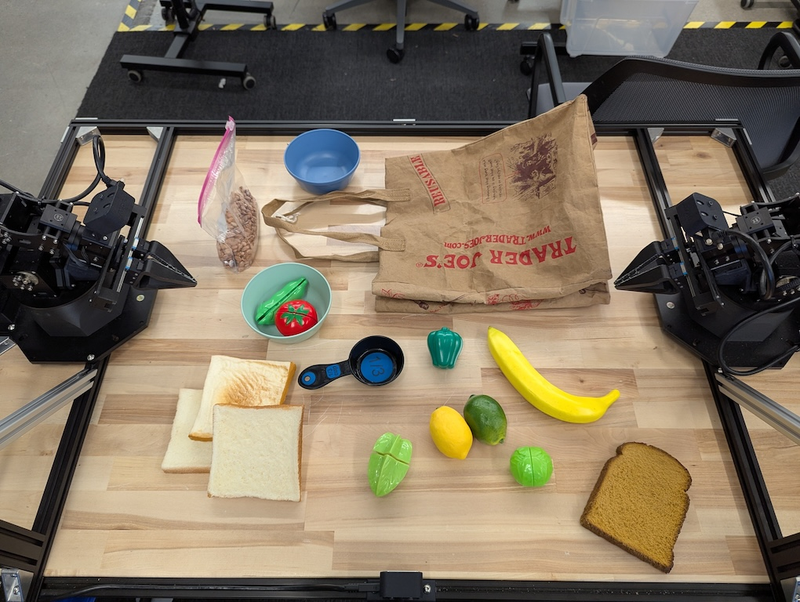

In [ ]:
img = get_image_resized("aloha-arms-table.png")

queries = [
    "bread",
    "starfruit",
    "banana",
]

prompt = textwrap.dedent(f"""\
Get all points matching the following objects: {', '.join(queries)}. The label
returned should be an identifying name for the object detected.

The answer should follow the JSON format:
[{{"point": <point>, "label": <label1>}}, ...]

The points are in [y, x] format normalized to 0-1000.
""")

start_time = time.time()
json_output = call_gemini_robotics_er(img, prompt)

points_data = []
try:
  data = json.loads(json_output)
  points_data.extend(data)
except json.JSONDecodeError:
  print("Warning: Invalid JSON response. Skipping.")

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json.dumps(points_data)))

### Point to all instances of an object based on more abstract description (e.g. "fruit")

```json
[
  {"point": [519, 368], "label": "fruit"},
  {"point": [699, 563], "label": "fruit"},
  {"point": [702, 608], "label": "fruit"},
  {"point": [624, 663], "label": "fruit"}
]
```

Total processing time: 1.7176 seconds



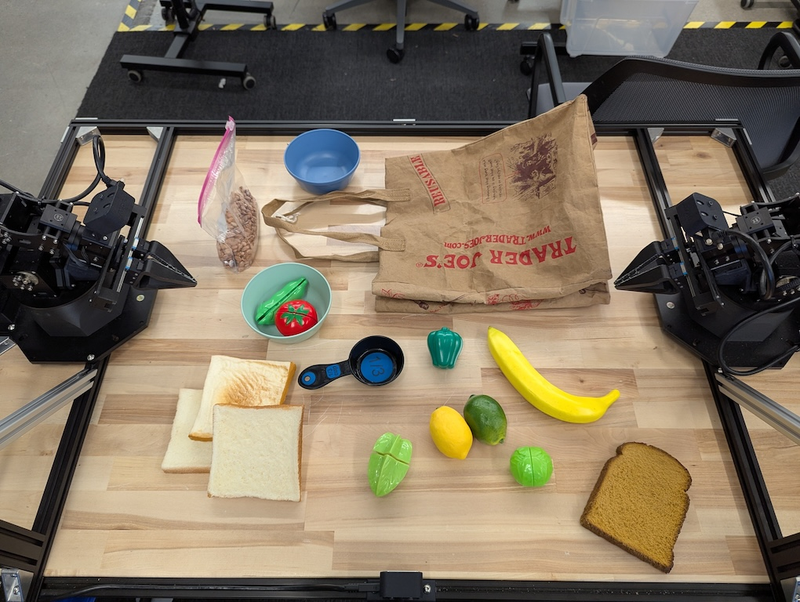

In [ ]:
points_data = []
img = get_image_resized("aloha-arms-table.png")

prompt = textwrap.dedent(f"""\
        Get all points for fruit. The label returned should be an identifying
        name for the object detected.

        The answer should follow the json format:
        [{{"point": <point>, "label": <label1>}}, ...]

        The points are in [y, x] format normalized to 0-1000.""")

start_time = time.time()
json_output = call_gemini_robotics_er(img, prompt)

try:
  data = json.loads(json_output)
  points_data.extend(data)
except json.JSONDecodeError:
  print(f"Warning: Invalid JSON response, skipping.")

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json.dumps(points_data)))

### Pointing to certain parts of an object in serial

```json
[
  {"point": [390, 485], "label": "handles"}
]
```
```json
[
  {"point": [564, 616], "label": "the stem of the banana"}
]
```
```json
[
  {"point": [609, 686], "label": "center of the banana"}
]
```
```json
[
  {"point": [763, 484], "label": "starfruit"}
]
```
```json
[
  {"point": [704, 608], "label": "lime"}
]
```
```json
[
  {"point": [308, 417], "label": "rim"}
]
```
```json
[
  {"point": [308, 412], "label": "rim of the dark blue bowl"}
]
```
```json
[
  {"point": [611, 477], "label": "rim"}
]
```
```json
[
  {"point": [619, 410], "label": "handle of the measuring cup"}
]
```
```json
[
  {"point": [521, 368], "label": "tomato"}
]
```

Total processing time: 13.2501 seconds



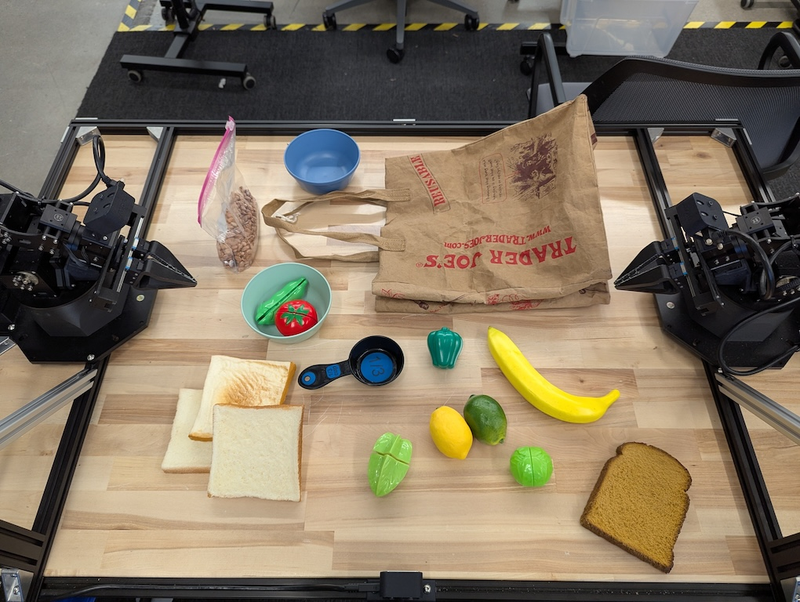

In [ ]:
img = get_image_resized("aloha-arms-table.png")
points_data = []

queries = [
    ("paper bag", "handles"),
    ("banana", "the stem"),
    ("banana", "center"),
    ("starfruit", "center"),
    ("lime", "center"),
    ("light blue bowl", "rim"),
    ("dark blue bowl", "rim"),
    ("measuring cup", "rim"),
    ("measuring cup", "handle"),
    ("bowl", "tomato"),
]

start_time = time.time()
for obj, part in queries:
  POINT_PROMPT_TEMPLATE = textwrap.dedent("""\
    Point to the $part of the $object in the image. Return the answer as a
    JSON list of a dictionary with keys 'point' and 'label'. Only return one
    point for this request.""")
  prompt = POINT_PROMPT_TEMPLATE.replace("$object", obj).replace("$part", part)

  json_output = call_gemini_robotics_er(img, prompt)

  try:
    data = json.loads(json_output)
    points_data.extend(data)
  except json.JSONDecodeError:
    print(f"Warning: Invalid JSON response for {obj}, {part}. Skipping.")
    continue

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json.dumps(points_data)))

As you can see in the example above, pointing to these objects in a loop can take a moment (e.g. 15 seconds). When possible, it is recommended that you run your queries in parallel to improve response time, as you can see in the following example.

### Pointing to certain parts of an object in parallel

```json
[
  {"point": [389, 412], "label": "handles"}
]
```
```json
[
  {"point": [609, 688], "label": "center of the banana"}
]
```
```json
[
  {"point": [704, 608], "label": "lime"}
]
```
```json
[
  {"point": [770, 485], "label": "starfruit"}
]
```
```json
[
  {"point": [564, 613], "label": "the stem of the banana"}
]
```
```json
[
  {"point": [232, 401], "label": "rim of the light blue bowl"}
]
```
```json
[
  {"point": [607, 479], "label": "rim of the measuring cup"}
]
```
```json
[
  {"point": [305, 400], "label": "rim of the dark blue bowl"}
]
```
```json
[
  {"point": [619, 411], "label": "handle of the measuring cup"}
]
```
```json
[
  {"point": [521, 368], "label": "tomato"}
]
```

Total processing time: 4.0269 seconds



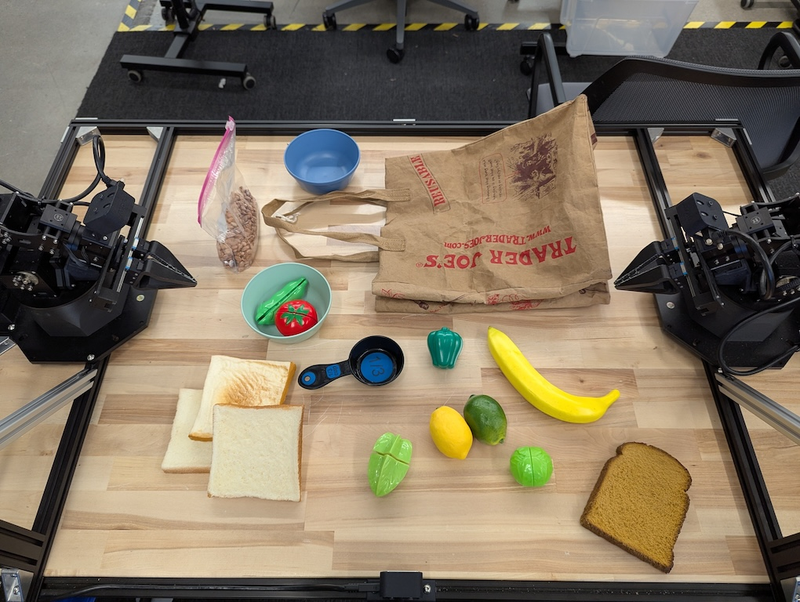

In [ ]:
import concurrent.futures

img = get_image_resized("aloha-arms-table.png")
points_data = []

queries = [
    ("paper bag", "handles"),
    ("banana", "the stem"),
    ("banana", "center"),
    ("starfruit", "center"),
    ("lime", "center"),
    ("light blue bowl", "rim"),
    ("dark blue bowl", "rim"),
    ("measuring cup", "rim"),
    ("measuring cup", "handle"),
    ("bowl", "tomato"),
]

def process_query(obj, part):
  POINT_PROMPT_TEMPLATE = textwrap.dedent("""\
    Point to the $part of the $object in the image. Return the answer as a
    JSON list of a dictionary with keys 'point' and 'label'. Only return one
    point for this request.""")
  prompt = POINT_PROMPT_TEMPLATE.replace("$object", obj).replace("$part", part)
  json_output = call_gemini_robotics_er(img, prompt)
  try:
    data = json.loads(json_output)
    return data
  except json.JSONDecodeError:
    print(f"Warning: Invalid JSON response for {obj}, {part}. Skipping.")
    return []

start_time = time.time()
with concurrent.futures.ThreadPoolExecutor() as executor:
  results = executor.map(
      lambda query: process_query(query[0], query[1]), queries
  )

for result in results:
  points_data.extend(result)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json.dumps(points_data)))

### Pointing to Defined Objects in a GIF

Successfully loaded GIF: aloha-pen.gif
Extracted 160 frames from the GIF.
Processing frame 1/160...
  Successfully parsed 3 points for frame 1.
Processing frame 11/160...
  Successfully parsed 3 points for frame 11.
Processing frame 21/160...
  Successfully parsed 3 points for frame 21.
Processing frame 31/160...
  Successfully parsed 4 points for frame 31.
Processing frame 41/160...
  Successfully parsed 3 points for frame 41.
Processing frame 51/160...
  Successfully parsed 3 points for frame 51.
Processing frame 61/160...
  Successfully parsed 3 points for frame 61.
Processing frame 71/160...
  Successfully parsed 4 points for frame 71.
Processing frame 81/160...
  Successfully parsed 4 points for frame 81.
Processing frame 91/160...
  Successfully parsed 3 points for frame 91.
Processing frame 101/160...
  Successfully parsed 4 points for frame 101.
Processing frame 111/160...
  Successfully parsed 3 points for frame 111.
Processing frame 121/160...
  Successfully parsed 4 points f

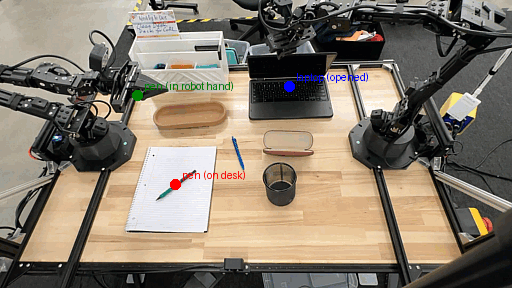

Displayed annotated GIF: /tmp/annotated_aloha_pen.gif


In [ ]:
gif_path = "aloha-pen.gif"
try:
  gif = Image.open(gif_path)
  print(f"Successfully loaded GIF: {gif_path}")
except FileNotFoundError:
  print(f"Error: GIF file not found at {gif_path}")
  raise

frames = extract_frames(gif)

# Define the objects to query
queries = [
    "pen (on desk)",
    "pen (in robot hand)",
    "laptop (opened)",
    "laptop (closed)",
]

prompt = textwrap.dedent(f"""\
Point to the following objects in the provided image: {", ".join(queries)}.

The answer should follow the JSON format:
[{{"point": <point>, "label": <label1>}}, ...]

The points are in [y, x] format normalized to 0-1000.

If no objects are found, return an empty JSON list [].""")


# Send every 10th frame as a separate request for the sake of time
analyzed_frames_data = []
frame_step = 10

for i in range(0, len(frames), frame_step):
  frame_index = i
  frame = frames[frame_index]
  print(f"Processing frame {frame_index+1}/{len(frames)}...")

  try:
    image_response = client.models.generate_content(
        model=MODEL_ID,
        contents=[frame, prompt],
        config=types.GenerateContentConfig(
            temperature=0.5,
            thinking_config=types.ThinkingConfig(thinking_budget=0),
        ),
    )

    try:
      json_output = parse_json(image_response.text)
      frame_points = json.loads(json_output)
      analyzed_frames_data.append(frame_points)
      print(
          f"  Successfully parsed {len(frame_points)} points for frame"
          f" {frame_index+1}."
      )
    except json.JSONDecodeError as e:
      print(
          f"  Error decoding JSON for frame {frame_index+1}: {e}. Appending"
          " empty list."
      )
      analyzed_frames_data.append([])
    except Exception as e:
      print(
          "  An unexpected error occurred processing frame"
          f" {frame_index+1} response: {e}. Appending empty list."
      )
      analyzed_frames_data.append([])

  except Exception as e:
    print(
        f"  Error generating content for frame {frame_index+1}: {e}. Appending"
        " empty list."
    )
    analyzed_frames_data.append([])


print(f"Collected point data for {len(analyzed_frames_data)} analyzed frames.")

points_data_all_frames = populate_points_for_all_frames(
    len(frames), frame_step, analyzed_frames_data
)
print(f"Populated point data for {len(points_data_all_frames)} total frames.")


modified_frames = overlay_points_on_frames(frames, points_data_all_frames)
display_gif(modified_frames)

## Object Detection and Bounding Boxes



In [ ]:
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-1-5-example-colab/aloha-arms-table.png -O aloha-arms-table.png -q

### 2D Bounding boxes

```json
[
  {"box_2d": [734, 725, 952, 865], "label": "bread slice"},
  {"box_2d": [544, 534, 614, 579], "label": "green bell pepper toy"},
  {"box_2d": [440, 303, 566, 412], "label": "light green bowl"},
  {"box_2d": [590, 236, 734, 368], "label": "bread slice"},
  {"box_2d": [674, 260, 834, 378], "label": "bread slice"},
  {"box_2d": [654, 579, 740, 633], "label": "lime toy"},
  {"box_2d": [718, 458, 824, 513], "label": "green apple toy"},
  {"box_2d": [646, 203, 784, 264], "label": "bread slice"},
  {"box_2d": [544, 608, 704, 780], "label": "banana toy"},
  {"box_2d": [496, 340, 560, 398], "label": "tomato toy"},
  {"box_2d": [158, 465, 520, 764], "label": "paper bag"},
  {"box_2d": [740, 636, 808, 690], "label": "green apple toy"},
  {"box_2d": [214, 354, 322, 450], "label": "blue bowl"},
  {"box_2d": [674, 538, 762, 592], "label": "lemon toy"},
  {"box_2d": [200, 250, 442, 327], "label": "bag of peanuts"},
  {"box_2d": [556, 372, 646, 506], "label": "measuring cup"}
]
```

Total p

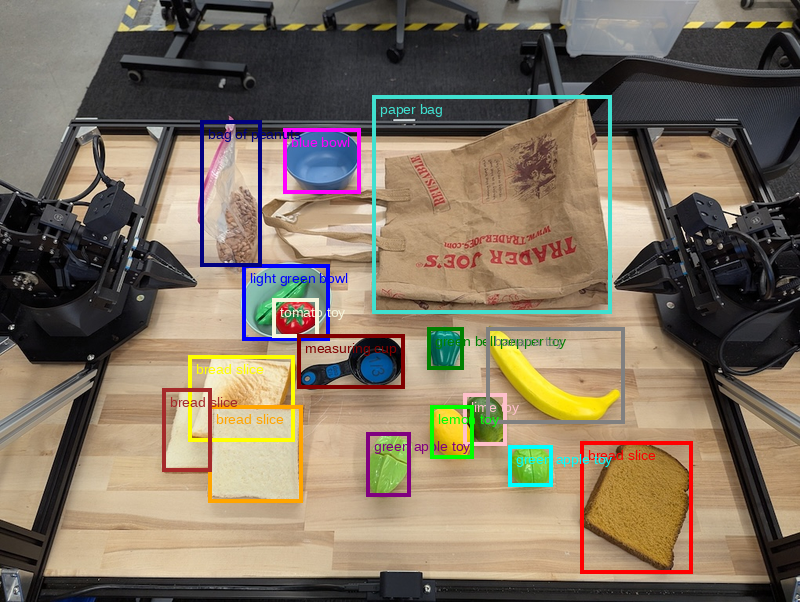

In [ ]:
img = get_image_resized("aloha-arms-table.png")

prompt = textwrap.dedent("""\
      Return bounding boxes as a JSON array with labels. Never return masks or
      code fencing. Limit to 25 objects. Include as many objects as you can
      identify on the table.
      If an object is present multiple times, name them according to their
      unique characteristic (colors, size, position, unique characteristics,
      etc..).
      The format should be as follows:
      [{"box_2d": [ymin, xmin, ymax, xmax], "label": <label for the object>}]
      normalized to 0-1000. The values in box_2d must only be integers.
""")

start_time = time.time()
json_output = call_gemini_robotics_er(img, prompt)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")

plot_bounding_boxes(img, json_output)
img

### Video Analysis

<video controls src="https://storage.googleapis.com/generativeai-downloads/images/robotics/er-1-5-example-colab/desk_organization.mp4" width=600px>


In [ ]:
myfile = client.files.upload(file="/content/desk_organization.mp4")
while myfile.state == "PROCESSING":
  print(".", end="")
  time.sleep(1)
  myfile = client.files.get(name=myfile.name)

if myfile.state.name == "FAILED":
  raise ValueError(myfile.state.name)

print("Uploaded")

prompt = textwrap.dedent("""\
    Describe in detail each step of finishing the task. Breaking it down by
    timestamp, output in JSON format with keys "start_timestamp",
    "end_timestamp" and "description".""")

start_time = time.time()

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[myfile, prompt],
    config=types.GenerateContentConfig(
        temperature=0.5,
        thinking_config=types.ThinkingConfig(thinking_budget=-1),
    ),
)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal processing time: {elapsed_time:.4f} seconds")

print(response.text)

FileNotFoundError: /content/desk_organization.mp4 is not a valid file path.

# TRACE


Get data from github

In [8]:
from google.colab import userdata
github_token = userdata.get('GITHUB')
if github_token:
  !git clone https://{github_token}@github.com/Trace-Datasets/trace-10-minute.git
else:
  print("GitHub token not found in environment variables.")

Cloning into 'trace-10-minute'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 45 (delta 20), reused 45 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 239.97 KiB | 14.12 MiB/s, done.
Resolving deltas: 100% (20/20), done.


In [ ]:
from google.genai import types
myfile = client.files.upload(file="/content/center_libx264_yuv420.mp4")
while myfile.state == "PROCESSING":
  print(".", end="")
  time.sleep(1)
  myfile = client.files.get(name=myfile.name)

if myfile.state.name == "FAILED":
  raise ValueError(myfile.state.name)

myfile_data = open(myfile.name, "rb").read()
print("Uploaded")

prompt = textwrap.dedent("""\
    Describe in detail each step of finishing the task. Breaking it down by
    timestamp, output in JSON format with keys "start_timestamp",
    "end_timestamp" and "description". Note which hand is used for each task by
    stating the chirality.
     """)

start_time = time.time()

response = client.models.generate_content(
    model=MODEL_ID,
    contents=types.Content(
        parts=[
            types.Part(
                inline_data=types.Blob(
                    data=myfile_data,
                    mime_type='video/mp4'),
                video_metadata=types.VideoMetadata(fps=2)
            ),
            types.Part(text=prompt),
            config=types.GenerateContentConfig(
                temperature=0.5,
                thinking_config=types.ThinkingConfig(thinking_budget=-1)
            )
        ]
    )
)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal processing time: {elapsed_time:.4f} seconds")

print(response.text)

.....Uploaded

Total processing time: 27.0978 seconds
```json
[
  {
    "start_timestamp": "00:11",
    "end_timestamp": "00:12",
    "description": "The person reaches for a white marker with their left hand and a black pen with their right hand, both located on the desk surface."
  },
  {
    "start_timestamp": "00:12",
    "end_timestamp": "00:14",
    "description": "The person picks up the white marker with their left hand and the black pen with their right hand."
  },
  {
    "start_timestamp": "00:14",
    "end_timestamp": "00:19",
    "description": "The person holds both objects in their hands, examining them briefly."
  },
  {
    "start_timestamp": "00:19",
    "end_timestamp": "00:22",
    "description": "The person moves their left hand, holding the white marker, towards a pen holder located on the left side of the desk."
  },
  {
    "start_timestamp": "00:22",
    "end_timestamp": "00:25",
    "description": "The person places the white marker into the pen holder using t

### Video Analysis: Time Range

In [ ]:
conversation_history = [
    {"role": "user", "parts": [{"text": prompt}]},
    {"role": "model", "parts": [{"text": response.text}]},
]

chat = client.chats.create(model=MODEL_ID, history=conversation_history)

prompt2 = textwrap.dedent("""\
    Zoom into second 15 to 24 and provide a per-second breakdown of what is
    happening in the same format. Always describe the action that happens in
    the left hand first, even if that action is simply continuing the previous
    motion or being still.""")

start_time = time.time()

response2 = chat.send_message([prompt2, myfile])

end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal processing time: {elapsed_time:.4f} seconds")

print(response2.text)


Total processing time: 14.8025 seconds
```json
[
  {
    "start_timestamp": "00:15",
    "end_timestamp": "00:16",
    "description": "The left hand holds the white marker over the desk, while the right hand holds the black pen nearby. Both hands move slightly as the person adjusts their position."
  },
  {
    "start_timestamp": "00:16",
    "end_timestamp": "00:17",
    "description": "The left hand continues to hold the white marker, maintaining its position above the desk. The right hand holds the black pen, also maintaining its position."
  },
  {
    "start_timestamp": "00:17",
    "end_timestamp": "00:18",
    "description": "The left hand, holding the white marker, begins to move towards the left side of the desk, in the direction of the pen holder. The right hand holds the black pen, moving slightly left along with the left hand."
  },
  {
    "start_timestamp": "00:18",
    "end_timestamp": "00:19",
    "description": "The left hand continues to move the white marker towards

Interestingly, stating this separation of left hand task and right hand task seems to avoid the issue of stating actions are simultaneous when they in fact are not. This may provide issues for actions that involve both hand coordination though. It also seems the prior context is overly biasing, since in 15seconds the pen is simply being picked up, and isnt actually moving towards the holder.

we see at the end the prior context being incorrect has caused the model to fail on its zoom in, since its likely been made to conform to whatever the top level timestamps are. This means that errors are going to cascade really badly if we get them early.

### Note
We are using different contexts here, and getting a fresh model, so no worries on context bleed.


In [ ]:
conversation_history = [
    {"role": "user", "parts": [{"text": prompt}]},
    {"role": "model", "parts": [{"text": response.text}]},
]

chat = client.chats.create(model=MODEL_ID, history=conversation_history)

prompt3 = textwrap.dedent("""\
    Zoom into second 15 to 24 and provide a per-second breakdown of what is
    happening in the same format. Always describe the action that happens in
    the left hand first, even if that action is simply continuing the previous
    motion or being still. Be wary of applying the overall context of the
    overarching timestamp too easily to the smaller tasks. For example, if the
    activity is to place an item ultimately into a vessel, that does not mean
    that each action leading to the completion of the task is necesarily moving
    the item towards such a vessel, as there may be intermediary tasks or
    motion. The larger timestamps from before also may have missed the end of an
    action, or have errors. Do not assume it is 100% true.""")

start_time = time.time()

response3 = chat.send_message([prompt3, myfile])

end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal processing time: {elapsed_time:.4f} seconds")

print(response3.text)


Total processing time: 22.3540 seconds
```json
[
  {
    "start_timestamp": "00:15",
    "end_timestamp": "00:16",
    "description": "The left hand holds the white marker in mid-air above the desk. The right hand holds the black pen in mid-air above the desk."
  },
  {
    "start_timestamp": "00:16",
    "end_timestamp": "00:17",
    "description": "The left hand begins to move the white marker towards the left side of the desk. The right hand continues to hold the black pen, remaining relatively stationary."
  },
  {
    "start_timestamp": "00:17",
    "end_timestamp": "00:18",
    "description": "The left hand moves the white marker further towards the left, aligning with the pen holder. The right hand holds the black pen in place."
  },
  {
    "start_timestamp": "00:18",
    "end_timestamp": "00:19",
    "description": "The left hand continues to move the white marker towards the pen holder, nearing the drop-off point. The right hand holds the black pen, adjusting slightly in pos

We see here despite the prompt attempt, the model has some training to be strict around timestamp consistency.

ModuleNotFoundError: No module named 'qwen_vl_utils'